In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-01-31 21:43:30.254562: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 21:43:35.880652: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 21:43:44.344902: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def generate_sine_wave(samples=10000):
    x = np.linspace(0, 100, samples)
    return np.sin(x)

series = generate_sine_wave()


In [3]:
np.random.seed(42)

anomaly_indices = np.random.choice(len(series), size=50, replace=False)
series_with_anomalies = series.copy()

series_with_anomalies[anomaly_indices] += np.random.uniform(3, 5, size=50)


In [4]:
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 50

X, y = create_sequences(series, window_size)


In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [6]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


In [7]:
model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(64),
    layers.Dense(1)
])


2026-01-31 21:47:56.810070: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(
    optimizer="adam",
    loss="mse"
)


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0299 - val_loss: 0.0016
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 9.6740e-04 - val_loss: 3.4853e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 1.3920e-04 - val_loss: 1.3878e-05
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.8190e-06 - val_loss: 3.4972e-06
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 3.2343e-06 - val_loss: 2.2092e-06
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 2.1271e-06 - val_loss: 1.5294e-06
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1.5845e-06 - val_loss: 2.3664e-06
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.1140e-06 - val_loss: 8.1492e-07
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 7.8347e-07 - val_loss: 6.9176e-07
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 5.4860e-07 - val_loss: 5.7054e-07


In [10]:
X_all, y_all = create_sequences(series_with_anomalies, window_size)
X_all = X_all[..., np.newaxis]


In [11]:
predictions = model.predict(X_all)


311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [12]:
prediction_error = np.abs(predictions.flatten() - y_all)


In [13]:
train_predictions = model.predict(X_train)
train_error = np.abs(train_predictions.flatten() - y_train)

threshold = np.percentile(train_error, 95)
print("Anomaly threshold:", threshold)


249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Anomaly threshold: 0.0014656171037623505


In [14]:
anomalies = prediction_error > threshold


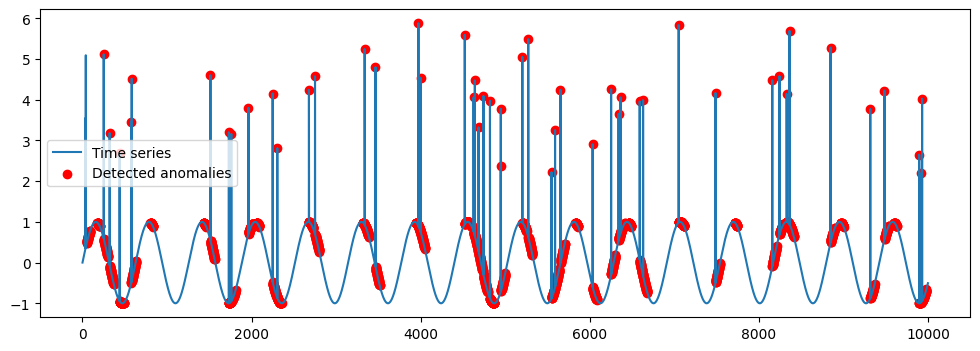

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(series_with_anomalies, label="Time series")

anomaly_points = np.where(anomalies)[0] + window_size
plt.scatter(
    anomaly_points,
    series_with_anomalies[anomaly_points],
    color="red",
    label="Detected anomalies"
)

plt.legend()
plt.show()
